# Introduction to Precipitation-based Climate Indices

> [!NOTE]
> The data shown in this repository is for **demonstration purposes only**. To obtain the full datasets for professional analysis, please use the official channels.

This notebook demonstrates how to compute and visualize **precipitation-based climate indices** from CMIP6 datasets using the `earthkit-climate` and `xclim` packages.

We'll use:
- **Precipitation-based indices**:
  - *SDII*: Simple Daily Intensity Index (average precipitation on wet days)
  - *CWD*: Consecutive Wet Days (max number of wet days in a row)

We’ll load **ACCESS-CM2 CMIP6 data** for both *historical* and *SSP585* scenarios.

In [1]:
import warnings

import cartopy.crs as ccrs
import earthkit.data as ekd
import earthkit.plots as ekp
import matplotlib.pyplot as plt

from earthkit.climate.indicators.precipitation import (
    daily_pr_intensity,
    maximum_consecutive_wet_days,
)

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)

## Loading CMIP6 data

We’ll use *daily gridded data* from the ACCESS-CM2 model for precipitation (`pr`), for both historical and SSP585 future scenarios.


In [2]:
# Load precipitation
pr_hist = ekd.from_source(
    "url",
    "https://sites.ecmwf.int/repository/earthkit-climate/pr_ACCESS-CM2_historical_reference.nc",
)
pr_ssp585 = ekd.from_source(
    "url",
    "https://sites.ecmwf.int/repository/earthkit-climate/pr_ACCESS-CM2_ssp585_far_future.nc",
)

## Inspect and visualize the raw data

Before computing indices, let’s plot an example grid to see how the raw precipitation looks.


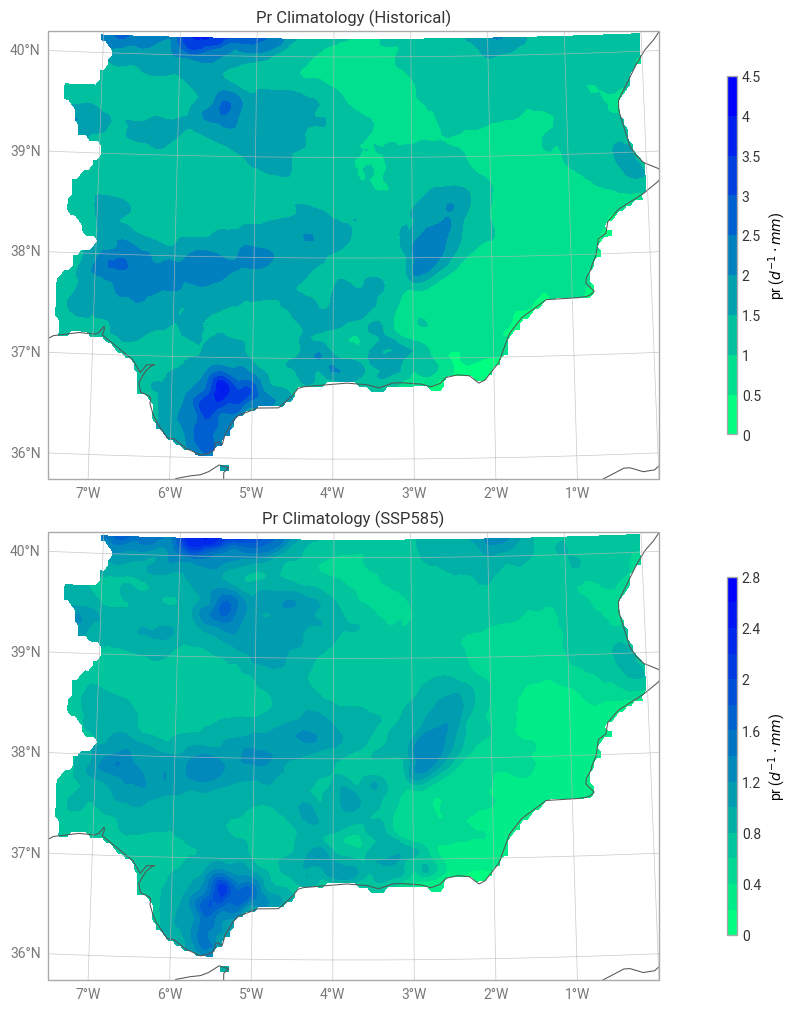

In [5]:
# Define domain (Spain north coast)
domain = [-7.5, 0, 35.8, 40.2]

# Create the figure with 2x3 maps
figure = ekp.Figure(
    crs=ccrs.NearsidePerspective(central_longitude=-3.75, central_latitude=38.0),
    rows=2,
    columns=1,
    size=(15, 10)
)

# Define variables and their datasets
variables = {
    "pr": (pr_hist, pr_ssp585, "mm/day"),
}

# HISTORICAL (row 0)
for col, (var, (hist, ssp, units)) in enumerate(variables.items()):
    hist_clim = hist.to_xarray().mean("time")
    cmap = "winter_r"
    style = ekp.styles.Style(colors=cmap, units=units)
    map_plot = figure.add_map(row=0, column=col, domain=domain)
    map_plot.quickplot(hist_clim, style=style)
    map_plot.coastlines()
    map_plot.gridlines()
    map_plot.legend(location="right")
    map_plot.title(f"{var} Climatology (Historical)")

# SSP585 (row 1)
for col, (var, (hist, ssp, units)) in enumerate(variables.items()):
    ssp_clim = ssp.to_xarray().mean("time")
    cmap = "winter_r"
    style = ekp.styles.Style(colors=cmap, units=units)
    map_plot = figure.add_map(row=1, column=col, domain=domain)
    map_plot.quickplot(ssp_clim, style=style)
    map_plot.coastlines()
    map_plot.gridlines()
    map_plot.legend(location="right")
    map_plot.title(f"{var} Climatology (SSP585)")

# Final layout
figure.show()

## Compute Simple Daily Intensity Index (SDII)

**SDII** measures the average precipitation amount on wet days (days with precipitation ≥ 1mm). We'll compute it for the SSP585 far-future scenario.


In [6]:
# Compute SDII
sdii = daily_pr_intensity(pr_ssp585.to_xarray())
sdii

<xarray.DataArray 'sdii' (time: 30, lat: 88, lon: 150)> Size: 3MB
dask.array<where, shape=(30, 88, 150), dtype=float64, chunksize=(3, 40, 40), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 240B 2071-01-01 2072-01-01 ... 2100-01-01
  * lat      (lat) float64 704B 35.82 35.87 35.92 35.97 ... 40.07 40.12 40.17
  * lon      (lon) float64 1kB -7.475 -7.425 -7.375 ... -0.125 -0.075 -0.025
    height   float64 8B ...
Attributes:
    units:          mm d-1
    cell_methods:   
    history:        [2026-03-11 16:06:08] sdii: SDII(pr=pr, thresh='1 mm/day'...
    standard_name:  lwe_thickness_of_precipitation_amount
    long_name:      Average precipitation during days with daily precipitatio...
    description:    Annual simple daily intensity index (sdii) or annual aver...

## Compute Consecutive Wet Days (CWD)

**CWD** calculates the maximum number of consecutive days with precipitation ≥ 1mm per period (annually in this case).


In [7]:
# Compute CWD
cwd = maximum_consecutive_wet_days(pr_ssp585.to_xarray())
cwd

<xarray.DataArray 'cwd' (time: 30, lat: 88, lon: 150)> Size: 3MB
dask.array<where, shape=(30, 88, 150), dtype=float64, chunksize=(1, 40, 40), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 240B 2071-01-01 2072-01-01 ... 2100-01-01
  * lat      (lat) float64 704B 35.82 35.87 35.92 35.97 ... 40.07 40.12 40.17
  * lon      (lon) float64 1kB -7.475 -7.425 -7.375 ... -0.125 -0.075 -0.025
    height   float64 8B ...
Attributes:
    units:          days
    cell_methods:    time: sum over days
    history:        [2026-03-11 16:06:13] cwd: CWD(pr=pr, thresh='1 mm/day', ...
    standard_name:  number_of_days_with_lwe_thickness_of_precipitation_amount...
    long_name:      Maximum consecutive days with daily precipitation at or a...
    description:    Annual maximum number of consecutive days with daily prec...

## Visualization of Precipitation Indices

Let’s visualize the climatologies (average across years) of these precipitation indices.


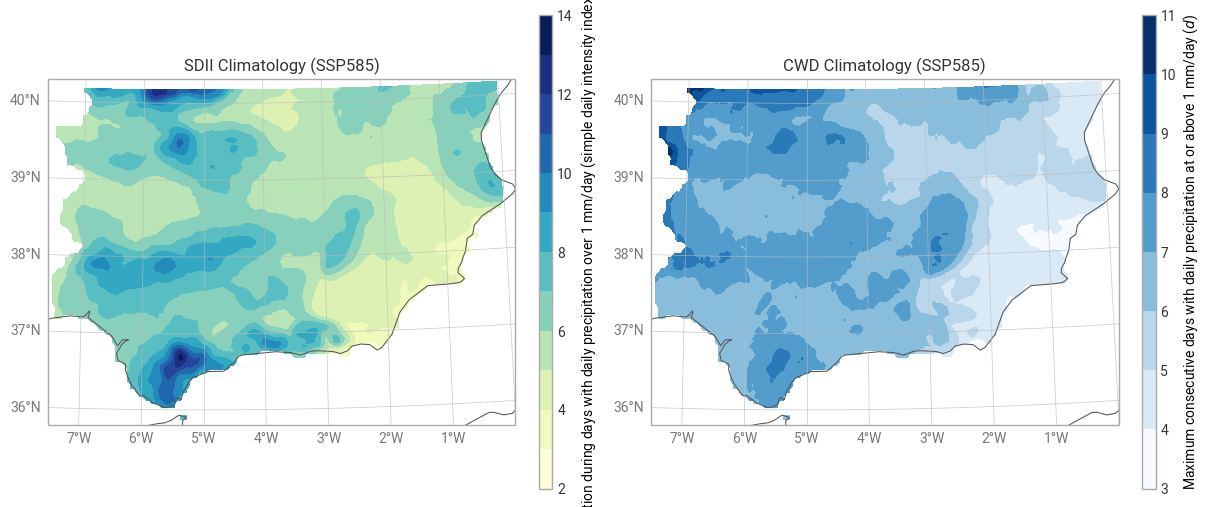

In [9]:
# Define domain (Southern Spain)
domain = [-7.5, 0, 35.8, 40.2]

# Create figure: 1 row (2 indices)
figure = ekp.Figure(
    crs=ccrs.NearsidePerspective(central_longitude=-5, central_latitude=43), rows=1, columns=2, size=(12, 6)
)

# Define indices and corresponding datasets
indices = {"SDII": sdii, "CWD": cwd}
cmaps = {"SDII": "YlGnBu", "CWD": "Blues"}
units = {"SDII": "mm d-1", "CWD": "days"}

# PLOT: Each index climatology
for col, (name, index_obj) in enumerate(indices.items()):
    ds = index_obj.mean("time")
    cmap = cmaps[name]

    style = ekp.styles.Style(colors=cmap, units=units[name])
    map_plot = figure.add_map(row=0, column=col, domain=domain)
    map_plot.quickplot(ds, style=style)
    map_plot.coastlines()
    map_plot.gridlines()
    map_plot.title(f"{name} Climatology (SSP585)")
    map_plot.legend(location="right")

figure.show()